# Introduction to sentiment analysis with TextBlob (based on NPS feedback texts)

Before we start, we import some preliminary libraries:

In [3]:
%pip install textblob

In [4]:
from textblob import TextBlob
from wordcloud import WordCloud

import numpy 
import os

import pandas as pd
import matplotlib.pyplot as plt



pd.set_option("display.max_colwidth", None)

Now we need to load NPS data (saved in a .csv format) to the working environment and read it into a pandas DataFrame

In [6]:
df = pd.read_csv('nps_feedback_example.csv', sep= ';') 
df

,date,Country,feedback,NPS,feedback_pro,feedback_con
0,13.01.2023,Austria,"Pro: I really liked your website, which is not fully loaded! ; Con: I prefer barrier-free website! People with visual impairment unfortunately do not get their desired information well.",1,"I really liked your website, which is not fully loaded!",I prefer barrier-free website! People with visual impairment unfortunately do not get their desired information well.
1,14.01.2023,Austria,"Con: Very slowly, maybe I'll find what I'm looking for...",0,NaN,"Very slowly, maybe I'll find what I'm looking for..."
2,15.01.2023,Austria,"Con: - Unfortunately, the website is difficult to use on mobile devices (long loading times, cumbersome operation) - ask less to give feedback (popup always appears at an inopportune moment when searching)",9,NaN,"- Unfortunately, the website is difficult to use on mobile devices (long loading times, cumbersome operation) - ask less to give feedback (popup always appears at an inopportune moment when searching)"
3,17.01.2023,Austria,Pro: I quickly found the customer service and was quickly taken care of. ; Con: It's all good.,10,I quickly found the customer service and was quickly taken care of.,It's all good.
4,19.01.2023,Austria,Pro: The dishwasher runs quietly. Price/performance ratio is ok. ; Con: It actually fits. Service ok,10,The dishwasher runs quietly. Price/performance ratio is ok.,It actually fits. Service ok
5,26.01.2023,Austria,Pro: The friendliness of the call center staff. ; Con: An overview of the availability of spare parts and how to equip technicians with the necessary spare parts before showing up for a service appointment.,7,The friendliness of the call center staff.,An overview of the availability of spare parts and how to equip technicians with the necessary spare parts before showing up for a service appointment.
6,26.01.2023,Austria,"Pro: Value for money! I have been using the Bosch 4405/05 for 40 years and have always received a new accessory over the years. Our family of originally 5 people - including 3 adolescents, always happy to eat - has now shrunk down to my husband and me - the Bosch food processor is still used almost every day. Thank you very much! I'm currently looking for a simple cookie resolution that can't be found at local retailers.",10,"Value for money! I have been using the Bosch 4405/05 for 40 years and have always received a new accessory over the years. Our family of originally 5 people - including 3 adolescents, always happy to eat - has now shrunk down to my husband and me - the Bosch food processor is still used almost every day. Thank you very much! I'm currently looking for a simple cookie resolution that can't be found at local retailers.",NaN
7,27.01.2023,Austria,Pro: Very clear. Wide range of spare parts. Good availability! ; Con: Spare parts prices are very high.,10,Very clear. Wide range of spare parts. Good availability!,Spare parts prices are very high.
8,29.01.2023,Austria,"Con: Pop-up windows constantly appear which make it difficult to view the pages. Overall, there is too much advertising on the home pages instead of factual information.",0,NaN,"Pop-up windows constantly appear which make it difficult to view the pages. Overall, there is too much advertising on the home pages instead of factual information."
9,29.01.2023,Austria,Pro: Clarity ; Con: more detailed descriptions,9,Clarity,more detailed descriptions


Let uns now conduct sentiment analysis and determine the polarity of NPS feedback texts.
The polarity score is a float within the range [-1.0, 1.0] where positive score is assigned to positive sentiment, a negative score to negative sentiment, and zero to neutral sentiment.


In [27]:
# Function to determine sentiment using TextBlob

def determine_sentiment(text):
    if isinstance(text, str):
        blob = TextBlob(text)
        return blob.sentiment.polarity
    else:
        return None

    
# Classify sentiment as positive, neutral, or negative
def classify_sentiment(polarity):
    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    elif numpy.isnan(polarity):
        return "n/a"
    else:
        return "neutral"

# Apply functions for sentiment analysis to each row in the DataFrame
df['feedback_pro_sentiment_score'] = df['feedback_pro'].apply(determine_sentiment)
df['feedback_pro_sentiment_text'] = df['feedback_pro_sentiment_score'].apply(classify_sentiment)

df['feedback_con_sentiment_score'] = df['feedback_con'].apply(determine_sentiment)
df['feedback_con_sentiment_text'] = df['feedback_con_sentiment_score'].apply(classify_sentiment)

# Print the DataFrame with extracted sentences and sentiment scores
df

,date,Country,feedback,NPS,feedback_pro,feedback_con,feedback_pro_sentiment_score,feedback_pro_sentiment_text,feedback_con_sentiment_score,feedback_con_sentiment_text
0,13.01.2023,Austria,"Pro: I really liked your website, which is not fully loaded! ; Con: I prefer barrier-free website! People with visual impairment unfortunately do not get their desired information well.",1,"I really liked your website, which is not fully loaded!",I prefer barrier-free website! People with visual impairment unfortunately do not get their desired information well.,0.750000,positive,0.125000,positive
1,14.01.2023,Austria,"Con: Very slowly, maybe I'll find what I'm looking for...",0,NaN,"Very slowly, maybe I'll find what I'm looking for...",NaN,n/a,-0.390000,negative
2,15.01.2023,Austria,"Con: - Unfortunately, the website is difficult to use on mobile devices (long loading times, cumbersome operation) - ask less to give feedback (popup always appears at an inopportune moment when searching)",9,NaN,"- Unfortunately, the website is difficult to use on mobile devices (long loading times, cumbersome operation) - ask less to give feedback (popup always appears at an inopportune moment when searching)",NaN,n/a,-0.304167,negative
3,17.01.2023,Austria,Pro: I quickly found the customer service and was quickly taken care of. ; Con: It's all good.,10,I quickly found the customer service and was quickly taken care of.,It's all good.,0.333333,positive,0.700000,positive
4,19.01.2023,Austria,Pro: The dishwasher runs quietly. Price/performance ratio is ok. ; Con: It actually fits. Service ok,10,The dishwasher runs quietly. Price/performance ratio is ok.,It actually fits. Service ok,0.250000,positive,0.250000,positive
5,26.01.2023,Austria,Pro: The friendliness of the call center staff. ; Con: An overview of the availability of spare parts and how to equip technicians with the necessary spare parts before showing up for a service appointment.,7,The friendliness of the call center staff.,An overview of the availability of spare parts and how to equip technicians with the necessary spare parts before showing up for a service appointment.,-0.100000,negative,0.000000,neutral
6,26.01.2023,Austria,"Pro: Value for money! I have been using the Bosch 4405/05 for 40 years and have always received a new accessory over the years. Our family of originally 5 people - including 3 adolescents, always happy to eat - has now shrunk down to my husband and me - the Bosch food processor is still used almost every day. Thank you very much! I'm currently looking for a simple cookie resolution that can't be found at local retailers.",10,"Value for money! I have been using the Bosch 4405/05 for 40 years and have always received a new accessory over the years. Our family of originally 5 people - including 3 adolescents, always happy to eat - has now shrunk down to my husband and me - the Bosch food processor is still used almost every day. Thank you very much! I'm currently looking for a simple cookie resolution that can't be found at local retailers.",NaN,0.165115,positive,NaN,n/a
7,27.01.2023,Austria,Pro: Very clear. Wide range of spare parts. Good availability! ; Con: Spare parts prices are very high.,10,Very clear. Wide range of spare parts. Good availability!,Spare parts prices are very high.,0.301667,positive,0.208000,positive
8,29.01.2023,Austria,"Con: Pop-up windows constantly appear which make it difficult to view the pages. Overall, there is too much advertising on the home pages instead of factual information.",0,NaN,"Pop-up windows constantly appear which make it difficult to view the pages. Overall, there is too much advertising on the home pages instead of factual information.",NaN,n/a,-0.075000,negative
9,29.01.2023,Austria,Pro: Clarity ; Con: more detailed descriptions,9,Clarity,more detailed descriptions,0.000000,neutral,0.450000,positive


Create wordclouds of positive and negative NPS feedback texts

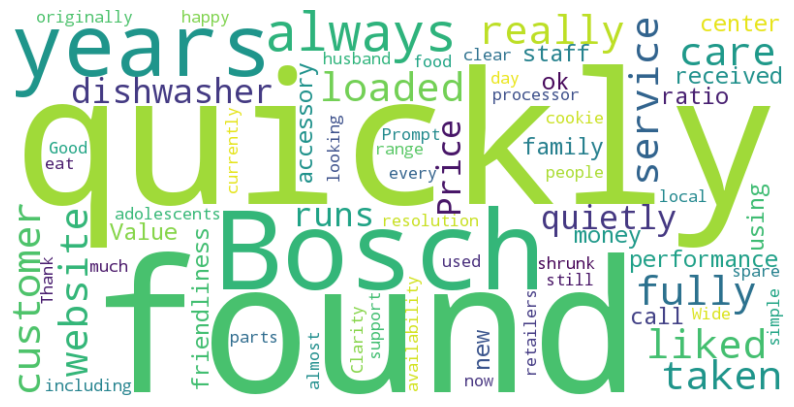

In [28]:
# Pro Feedback

# Concatenate text
filtered_texts = df['feedback_pro'].dropna()
text = ' '.join(filtered_texts)

# Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

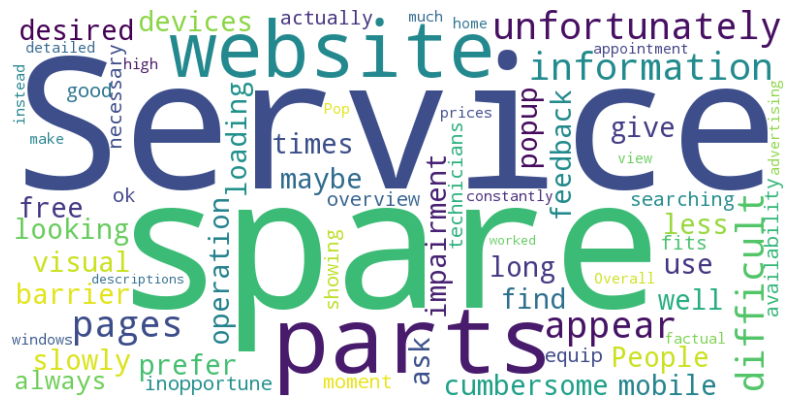

In [29]:
# Con feedback

# Concatenate text
filtered_texts = df['feedback_con'].dropna()
text = ' '.join(filtered_texts)

# Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()